In [41]:
library(data.table)
library(dplyr)
library(ggplot2)
library(qqman)
library(MASS)  # for mvrnorm to generate correlated data
options(repr.plot.width = 15, repr.plot.height = 12)

## Simulating GWAS Datasets with Linkage Disequilibrium

GWAS identifies statistical asociations between genetic variants and phenotypes, but genetic variants in human genome arent independent.

Due to inheritance patterns, nearby variants tend to be correlated: a phenomenon known as **linkage disequilibrium (LD)**

### Linkage Disequilibrium

**Linkage Disequilibrium (LD)** is the non-random association of alleles at different loci in a population. 

- SNPs that are physically close on a chromosome tend to be inherited together
- This creates **correlation** between nearby genetic variants
- LD decays with physical distance due to recombination
- Measured by $r^2$ score usually

Note: LD matters for GWAS because a detected association signal might not always be due to a causal variant, it could be due to a correlated one in linkage diseq. with it. Hence, ignoring LD will lead to unrealistic simulations.

### Simulation Model

The phenotype model is still:
$$ y = X \cdot \beta + \epsilon $$

**difference:** The genotype matrix $X$ is now generated with correlation structure:
- SNPs close together have higher correlation
- LD decays exponentially with distance
- $\text{Cor}(\text{SNP}_i, \text{SNP}_j) = \rho^{|i-j|}$ where $\rho$ is the LD decay parameter

### Parameter Specification

In [43]:
set.seed(42)

n_individuals <- 2000      # Number of samples
n_snps <- 10000            # Number of SNPs
n_causal <- 20             # Number of causal variants
heritability <- 0.4        # Proportion of variance explained genetically
ld_decay <- 0.95           # LD decay parameter (0.9-0.99 typical for nearby SNPs)

### Minor Allele Frequencies (MAF)

Generate MAF for each SNP, sampled uniformly between 0.05 and 0.5

(self reminder: MAF is fraction of chromosomes in population carrying the minor allele)

In [45]:
maf <- runif(n_snps, min = 0.05, max = 0.5)

### Genotype Matrix with Linkage Disequilibrium

(self reminder: genotype matrix contains rows as individuals and columns as SNPs)

- we will make a correlation matrix where nearby SNPs are correlated
- we'll generate correlated continuous variables using multivariate normal distribution
- finally convert them to discrete genotypes (0, 1, 2) using quantile transformation

**LD Structure:**
$$ \Sigma_{ij} = \rho^{|i-j|} $$

This creates an **exponential decay** in LD with distance between SNPs.

In [46]:
# Create correlation matrix with exponential decay
# For computational efficiency, we'll simulate in blocks
block_size <- 500  # (500 SNPs at a time)
n_blocks <- ceiling(n_snps / block_size)

genotypes <- matrix(0, nrow = n_individuals, ncol = n_snps)

cat("simulating genotypes with LD...\n")

for (block in 1:n_blocks) {
  start_idx <- (block - 1) * block_size + 1
  end_idx <- min(block * block_size, n_snps)
  block_snps <- end_idx - start_idx + 1
  
  # Create correlation matrix for this block
  Sigma <- matrix(1, nrow = block_snps, ncol = block_snps)
  for (i in 1:block_snps) {
    for (j in 1:block_snps) {
      if (i != j) {
        Sigma[i, j] <- ld_decay^abs(i - j)
      }
    }
  }
  
  # Generate correlated normal variables
  Z <- mvrnorm(n = n_individuals, mu = rep(0, block_snps), Sigma = Sigma)
  
  # Convert to genotypes using MAF-specific thresholds
  for (j in 1:block_snps) {
    snp_idx <- start_idx + j - 1
    p <- maf[snp_idx]
    
    # Calculate thresholds for 0, 1, 2 genotypes under HWE
    threshold_0 <- qnorm((1-p)^2)  # Prob of 0 copies
    threshold_1 <- qnorm((1-p)^2 + 2*p*(1-p))  # Prob of 0 or 1 copy
    
    genotypes[, snp_idx] <- ifelse(Z[, j] < threshold_0, 0,
                                    ifelse(Z[, j] < threshold_1, 1, 2))
  }
  
  if (block %% 5 == 0) {
    cat(sprintf("  block %d/%d complete\n", block, n_blocks))
  }
}

cat("genotype simulation complete!\n")

simulating genotypes with LD...
  block 5/20 complete
  block 10/20 complete
  block 15/20 complete
  block 20/20 complete
genotype simulation complete!


LD Structure verification

checking if LD was actually created by computing pairwise correlations between different SNPs

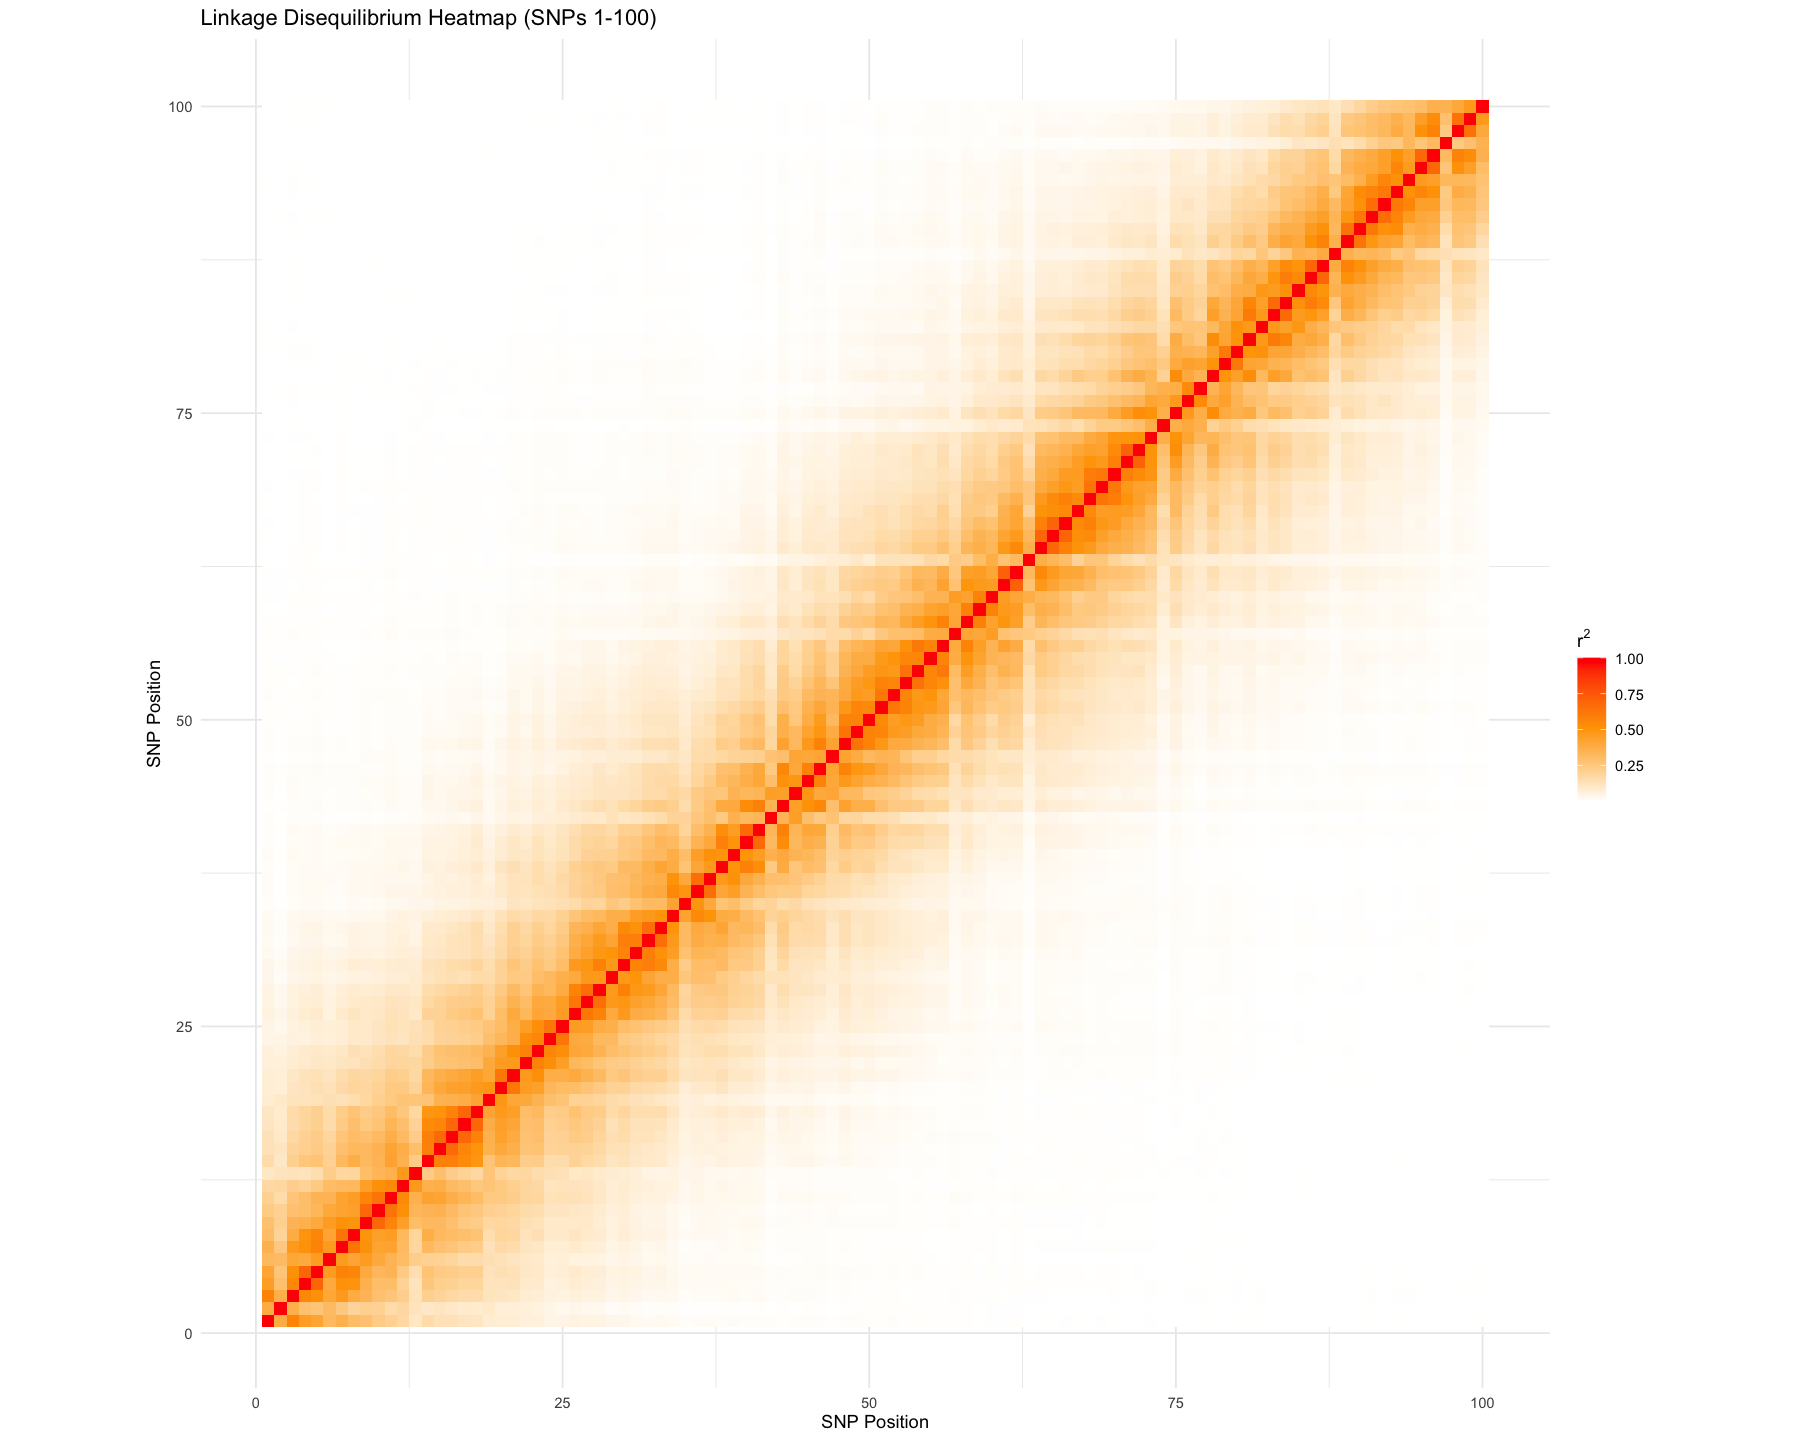

In [47]:
# Calculate LD (r^2) for a subset of SNPs to visualize
test_region <- 1:100  # First 100 SNPs
ld_matrix <- cor(genotypes[, test_region])^2

# Create LD heatmap
ld_df <- expand.grid(SNP1 = test_region, SNP2 = test_region)
ld_df$r2 <- as.vector(ld_matrix)

ggplot(ld_df, aes(x = SNP1, y = SNP2, fill = r2)) +
  geom_tile() +
  scale_fill_gradient2(low = "white", high = "red", mid = "orange", midpoint = 0.5,
                       name = expression(r^2)) +
  theme_minimal() +
  labs(title = "Linkage Disequilibrium Heatmap (SNPs 1-100)",
       x = "SNP Position",
       y = "SNP Position") +
  theme(aspect.ratio = 1)

### LD Decay Plot

Visualize how LD decays with distance between SNPs.
(as expected, nearby SNPs are correlated, and when distance inc, correlation dec.)

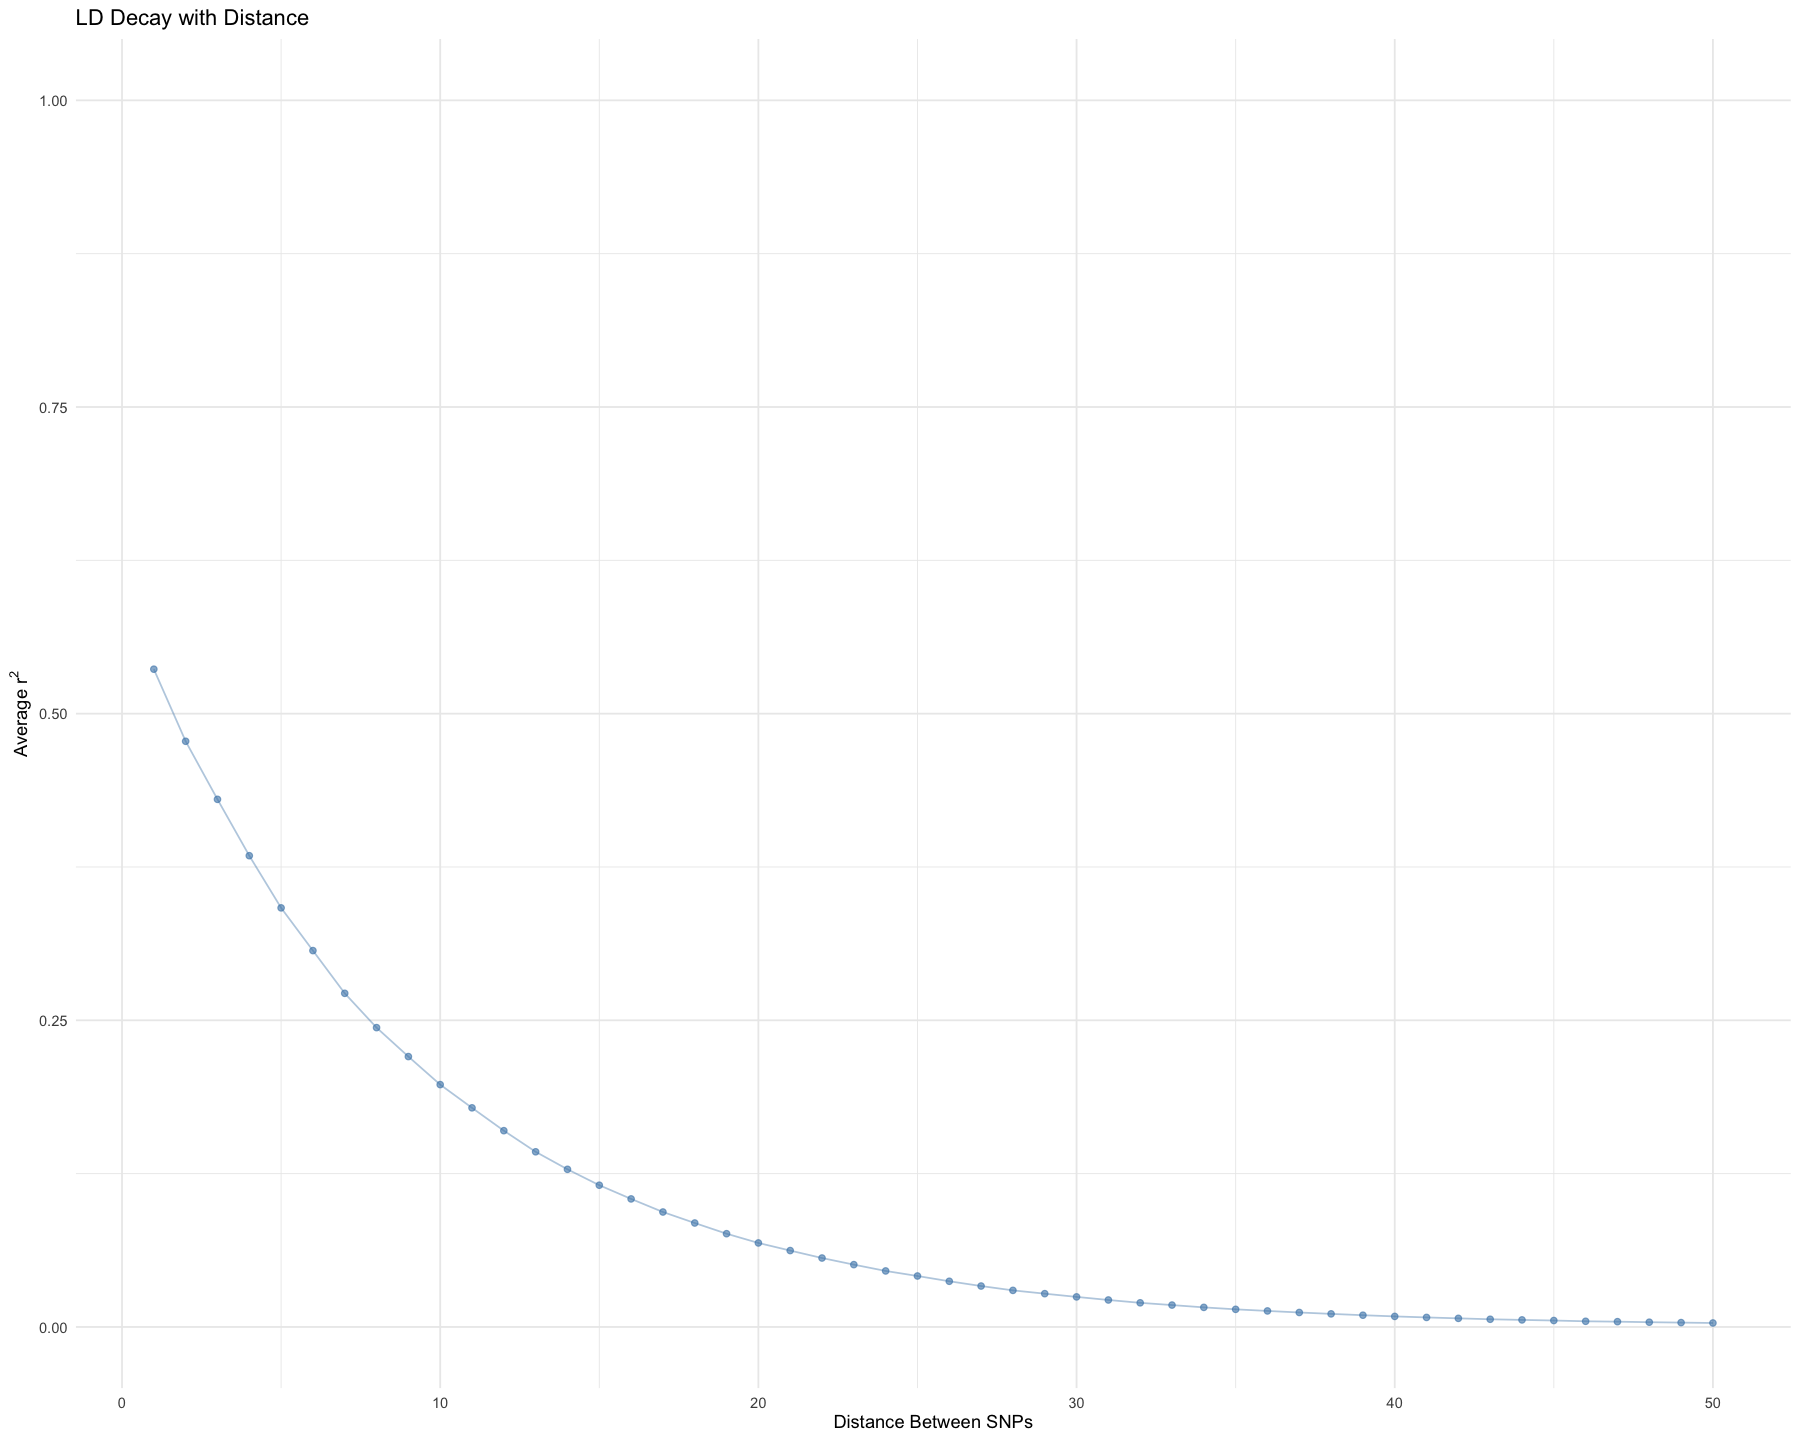

In [48]:
# Calculate average r^2 as a function of distance
max_dist <- 50
distances <- 1:max_dist
avg_r2 <- numeric(max_dist)

test_snps <- 1:500  # Use first 500 SNPs for efficiency

# Calculate LD matrix for the test SNPs
test_ld_matrix <- cor(genotypes[, test_snps])^2

for (d in distances) {
  pairs <- which(row(test_ld_matrix) == col(test_ld_matrix) + d)
  if (length(pairs) > 0) {
    avg_r2[d] <- mean(test_ld_matrix[pairs])
  }
}

ld_decay_df <- data.frame(Distance = distances, AvgR2 = avg_r2)

ggplot(ld_decay_df, aes(x = Distance, y = AvgR2)) +
  geom_point(alpha = 0.6, color = "steelblue") +
  geom_line(alpha = 0.4, color = "steelblue") +
  theme_minimal() +
  labs(title = "LD Decay with Distance",
       x = "Distance Between SNPs",
       y = expression(paste("Average ", r^2))) +
  ylim(0, 1)

### Define Causal Variants

Randomly select causal SNPs that will have true effects on the phenotype.

In [49]:
causal_snps <- sample(1:n_snps, n_causal)
cat("Causal SNPs:", head(causal_snps, 10), "...\n")

Causal SNPs: 9401 2180 913 2640 1593 9570 2835 2922 1944 7108 ...


### Effect Sizes (β)

Sample effect sizes from a normal distribution for causal variants only.

In [50]:
beta <- rep(0, n_snps)
beta[causal_snps] <- rnorm(n_causal, mean = 0, sd = 0.2)

cat("Number of non-zero effects:", sum(beta != 0), "\n")

Number of non-zero effects: 20 


### Generate Phenotypes

Create phenotypes as a combination of genetic effects and environmental noise:

$$ y = \sum_{j} G_j \beta_j + \epsilon $$

Where:
- $G_j$ is the genotype at SNP $j$
- $\beta_j$ is the effect size (non-zero only for causal SNPs)
- $\epsilon$ is environmental noise scaled to achieve desired heritability

In [51]:
# Calculate genetic score
genetic_score <- genotypes %*% beta

# Calculate variance of environmental noise to achieve target heritability
var_g <- var(genetic_score)
var_e <- var_g * (1 - heritability) / heritability

# Generate environmental noise
environmental_noise <- rnorm(n_individuals, mean = 0, sd = sqrt(var_e))

# Final phenotype
phenotype <- as.numeric(genetic_score + environmental_noise)

cat("Phenotype statistics:\n")
cat("  Mean:", mean(phenotype), "\n")
cat("  SD:", sd(phenotype), "\n")
cat("  Estimated heritability:", var(genetic_score) / var(phenotype), "\n")

Phenotype statistics:
  Mean: 0.6089693 
  SD: 1.011337 
  Estimated heritability: 0.3998179 


### SNP-wise Association Testing

Perform linear regression for each SNP individually:
$$ y = \beta_0 + \beta_1 \cdot \text{SNP} + \epsilon $$

This tests the marginal association of each SNP with the phenotype.

In [53]:
cat("Running GWAS association tests...\n")

gwas_results <- lapply(1:n_snps, function(j) {
  if (j %% 1000 == 0) cat("  SNP", j, "/", n_snps, "\n")
  
  model <- lm(phenotype ~ genotypes[, j])
  summary_model <- summary(model)
  
  data.frame(
    beta = summary_model$coefficients[2, 1],
    se = summary_model$coefficients[2, 2],
    p_value = summary_model$coefficients[2, 4]
  )
})

gwas_results <- bind_rows(gwas_results)
cat("GWAS complete!\n")

Running GWAS association tests...
  SNP 1000 / 10000 
  SNP 2000 / 10000 
  SNP 3000 / 10000 
  SNP 4000 / 10000 
  SNP 5000 / 10000 
  SNP 6000 / 10000 
  SNP 7000 / 10000 
  SNP 8000 / 10000 
  SNP 9000 / 10000 
  SNP 10000 / 10000 
GWAS complete!


### Add Metadata

Add SNP identifiers, chromosome, and position information to mirror real GWAS summary statistics.

In [54]:
gwas_results <- gwas_results %>%
  mutate(
    SNP = paste0("rs", 1:n_snps),
    CHR = sample(1:22, n_snps, replace = TRUE),
    BP = cumsum(sample(1000:5000, n_snps, replace = TRUE)),  # Cumulative positions
    is_causal = 1:n_snps %in% causal_snps
  )

# Summary statistics
cat("\nGWAS Results Summary:\n")
cat("  Total SNPs:", nrow(gwas_results), "\n")
cat("  Genome-wide significant (p < 5e-8):", sum(gwas_results$p_value < 5e-8), "\n")
cat("  Suggestive (p < 1e-5):", sum(gwas_results$p_value < 1e-5), "\n")
cat("  True causal variants:", sum(gwas_results$is_causal), "\n")
cat("  Causal variants detected (p < 5e-8):", 
    sum(gwas_results$is_causal & gwas_results$p_value < 5e-8), "\n")


GWAS Results Summary:
  Total SNPs: 10000 
  Genome-wide significant (p < 5e-8): 60 
  Suggestive (p < 1e-5): 120 
  True causal variants: 20 
  Causal variants detected (p < 5e-8): 11 


### Impact of LD on Association Signals

Due to LD, we expect to see:
1. **Tag SNPs**: Non-causal SNPs correlated with causal variants showing association
2. **Extended association regions**: Clusters of significant SNPs rather than isolated signals
3. **Weaker signals**: Dilution of effect through correlation

In [56]:
# Examine SNPs near causal variants
window_size <- 50

for (causal_idx in head(causal_snps, 3)) {
  start <- max(1, causal_idx - window_size)
  end <- min(n_snps, causal_idx + window_size)
  window <- start:end
  
  cat(sprintf("\nRegion around causal SNP %d (rs%d):\n", causal_idx, causal_idx))
  cat(sprintf("  Causal SNP p-value: %.2e\n", gwas_results$p_value[causal_idx]))
  cat(sprintf("  Min p-value in window: %.2e\n", min(gwas_results$p_value[window])))
  cat(sprintf("  Significant SNPs in window (p<1e-5): %d\n", 
              sum(gwas_results$p_value[window] < 1e-5)))
}


Region around causal SNP 9401 (rs9401):
  Causal SNP p-value: 1.78e-08
  Min p-value in window: 1.78e-08
  Significant SNPs in window (p<1e-5): 2

Region around causal SNP 2180 (rs2180):
  Causal SNP p-value: 2.60e-06
  Min p-value in window: 2.60e-06
  Significant SNPs in window (p<1e-5): 1

Region around causal SNP 913 (rs913):
  Causal SNP p-value: 1.51e-26
  Min p-value in window: 1.51e-26
  Significant SNPs in window (p<1e-5): 20


## Visualization of Results

### Manhattan Plot

With LD, we expect to see:
- Broader peaks (not just single SNPs, but many SNPs as part of the peak)
- Multiple significant SNPs clustered together

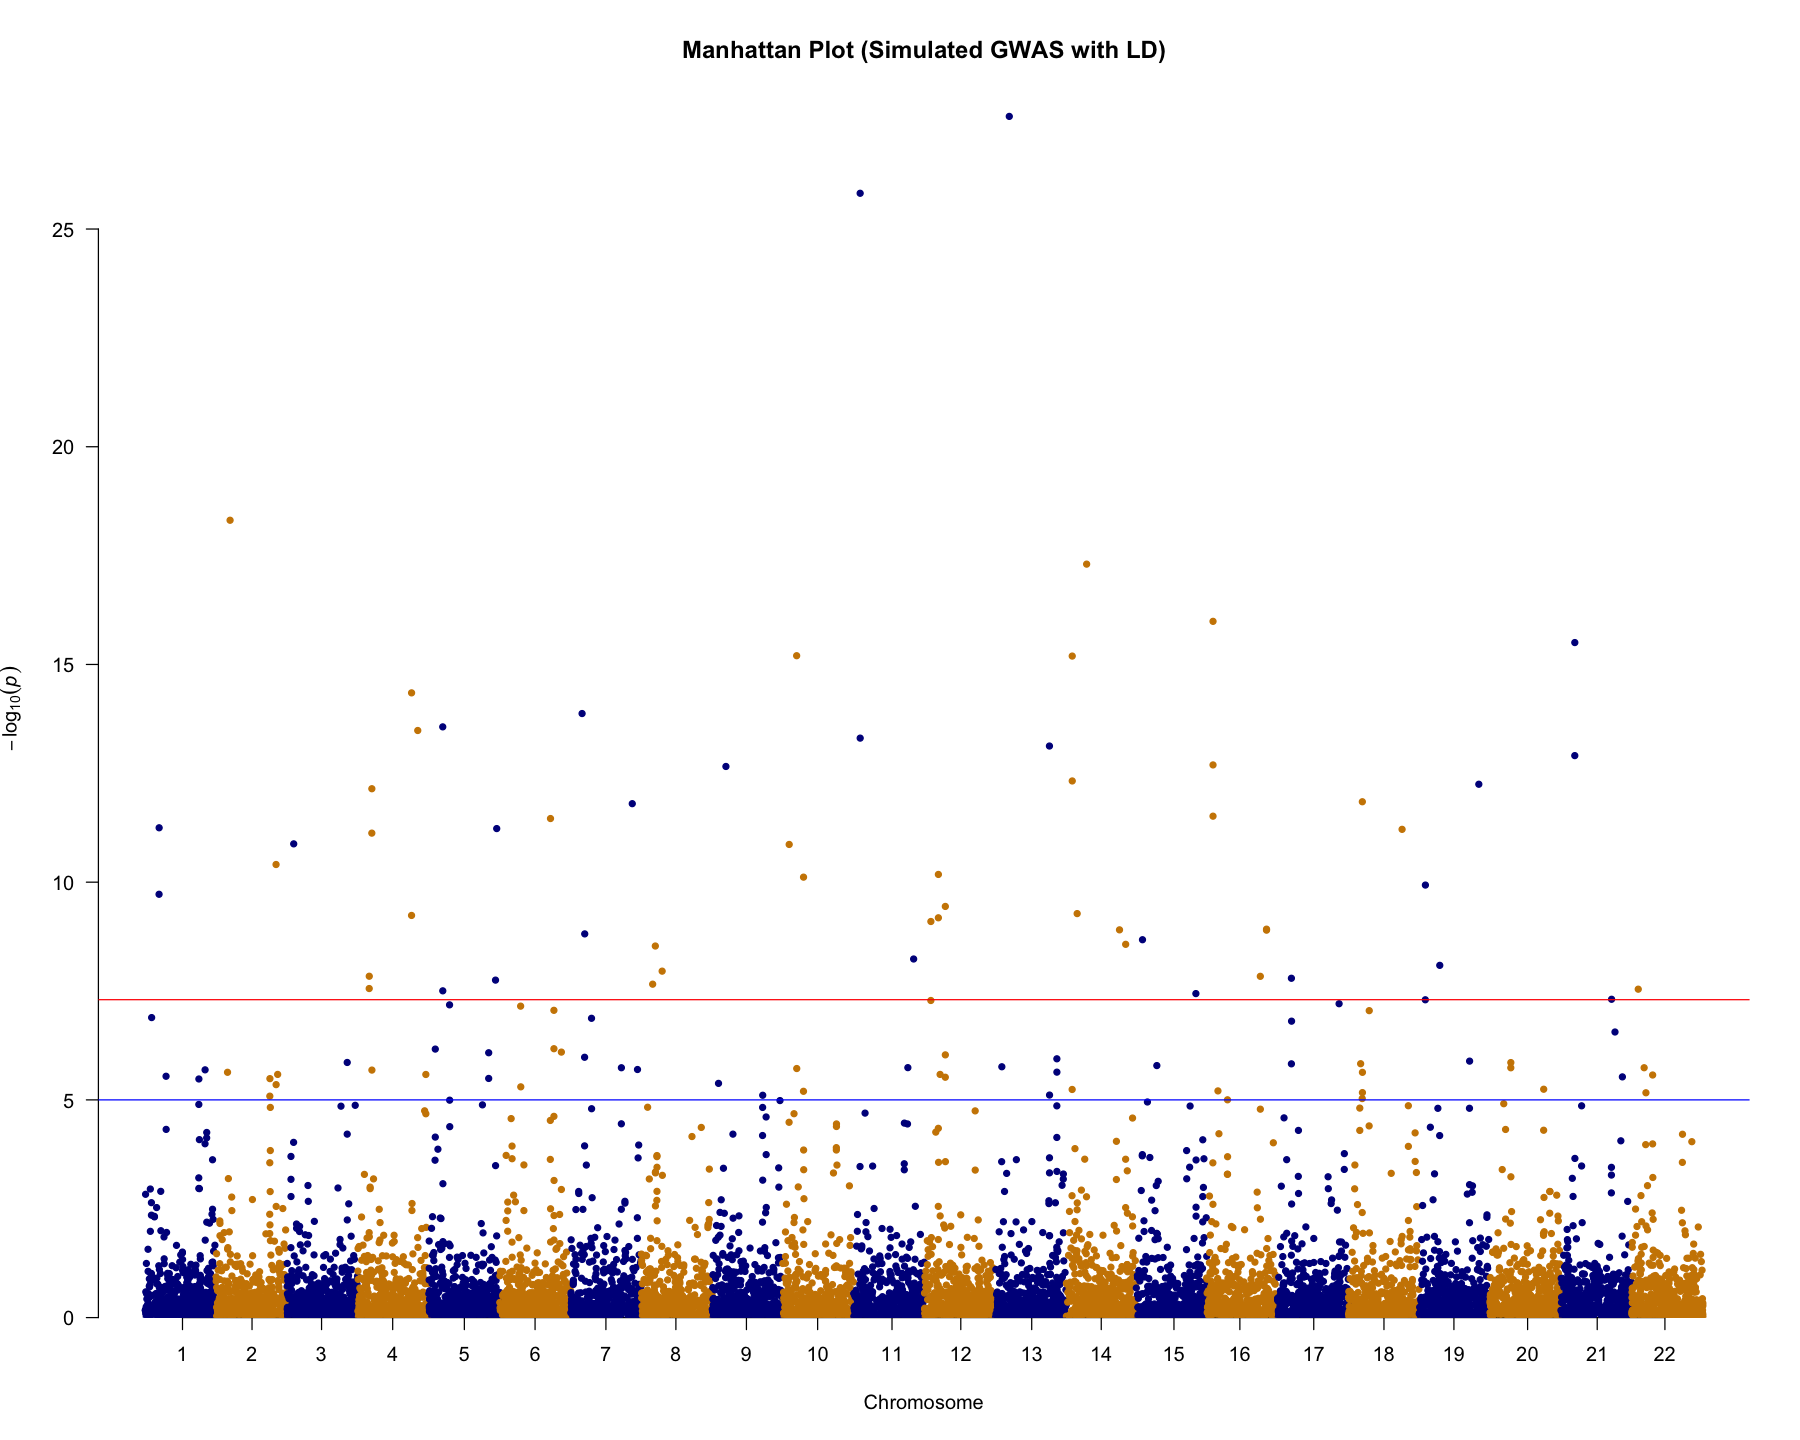

In [57]:
manhattan(
  gwas_results,
  chr = "CHR",
  bp = "BP",
  snp = "SNP",
  p = "p_value",
  genomewideline = -log10(5e-8),
  suggestiveline = -log10(1e-5),
  main = "Manhattan Plot (Simulated GWAS with LD)",
  col = c("blue4", "orange3")
)

### Q-Q Plot

Compares observed vs. expected p-value distribution.
- Deviation from diagonal indicates true associations
- Early deviation suggests population stratification or inflation

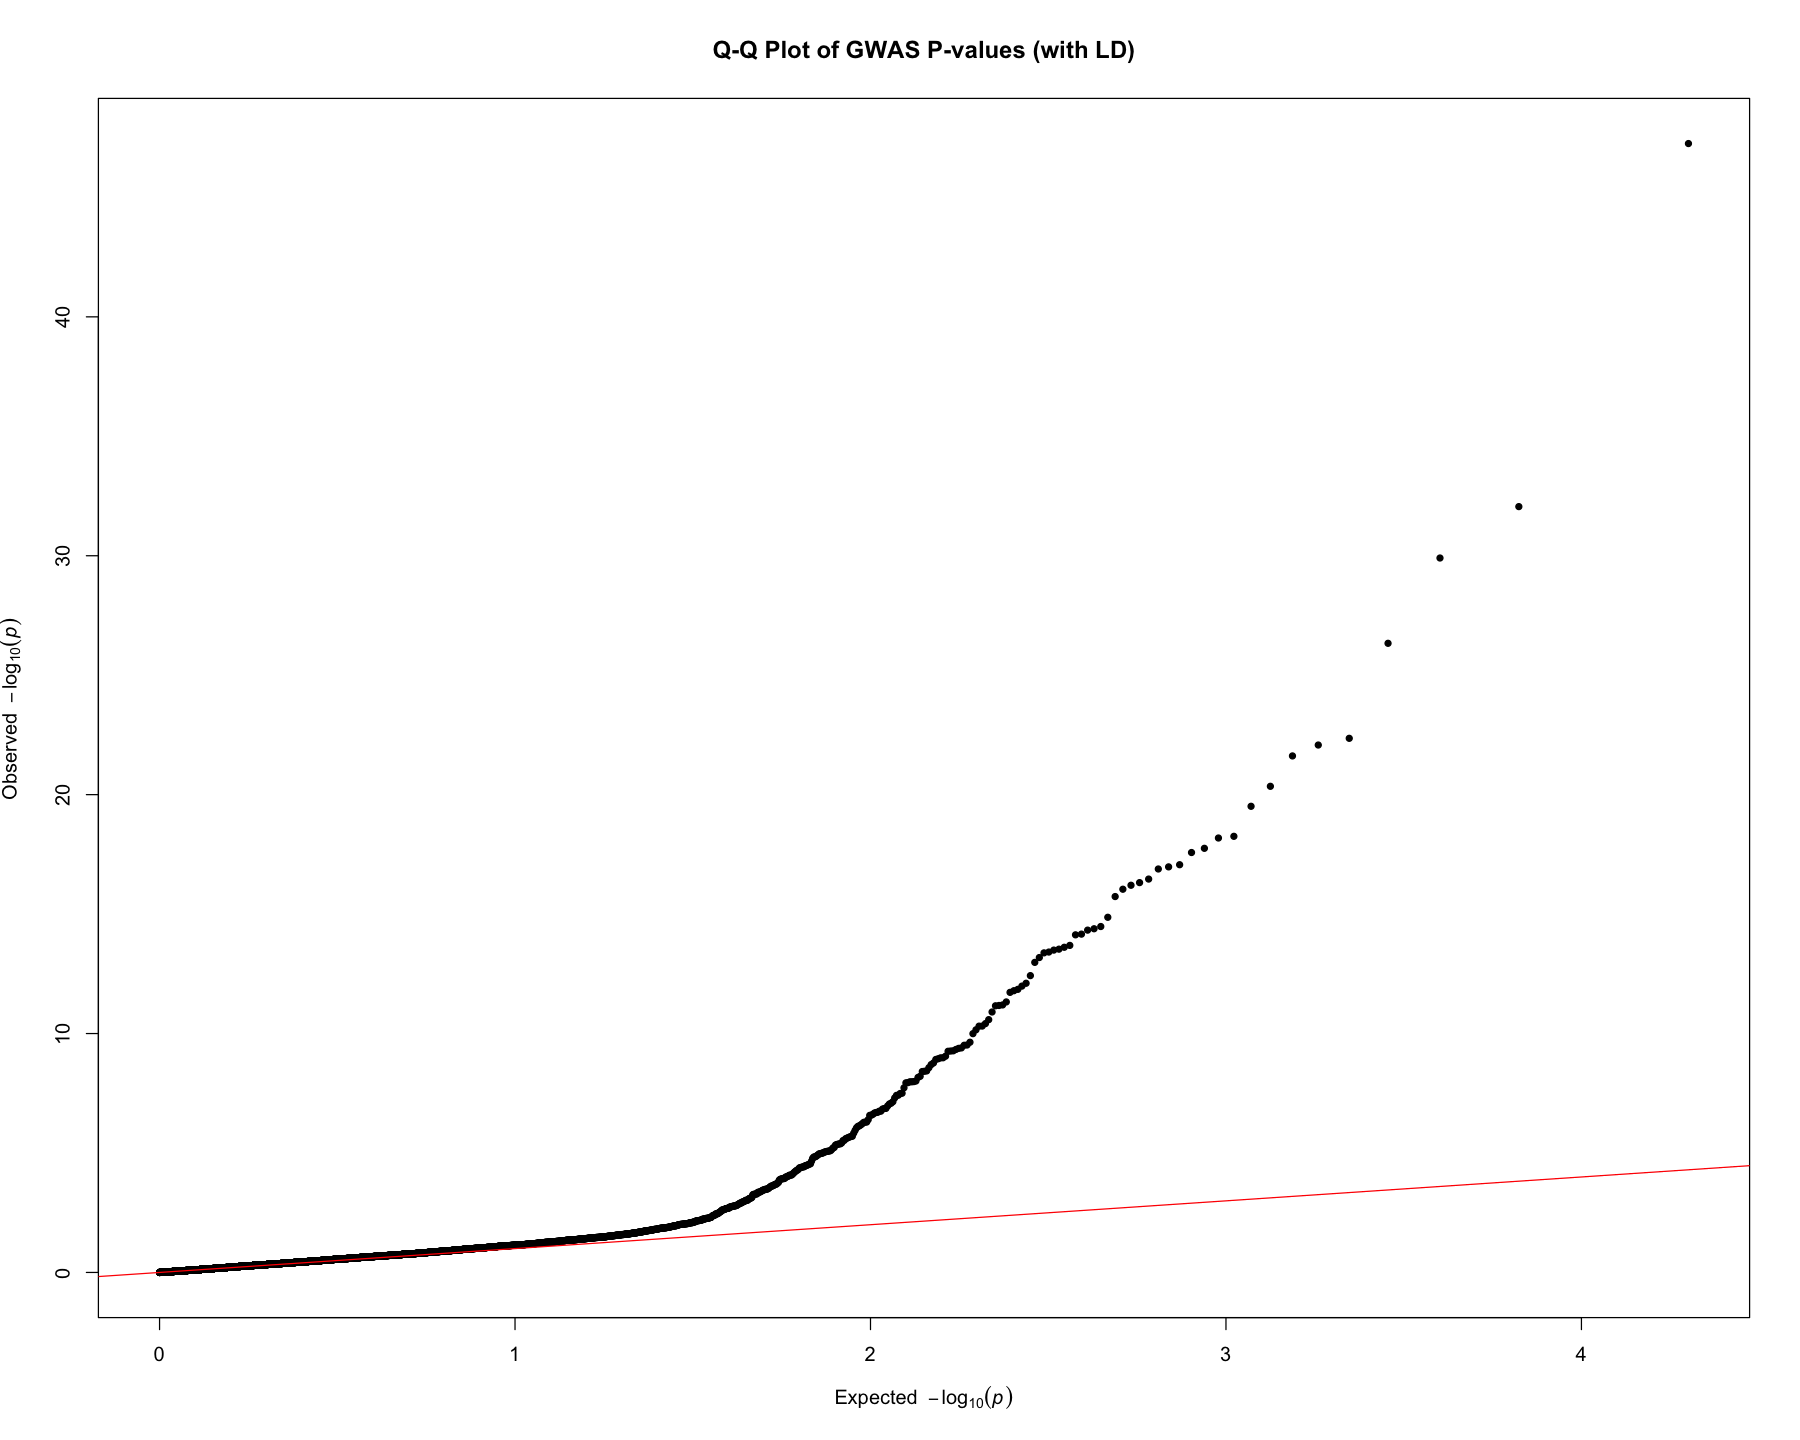

In [38]:
qq(gwas_results$p_value, main = "Q-Q Plot of GWAS P-values (with LD)")

### Volcano Plot

Shows effect size vs. significance. Highlights SNPs with both:
- Large effect sizes (x-axis)
- High significance (y-axis)

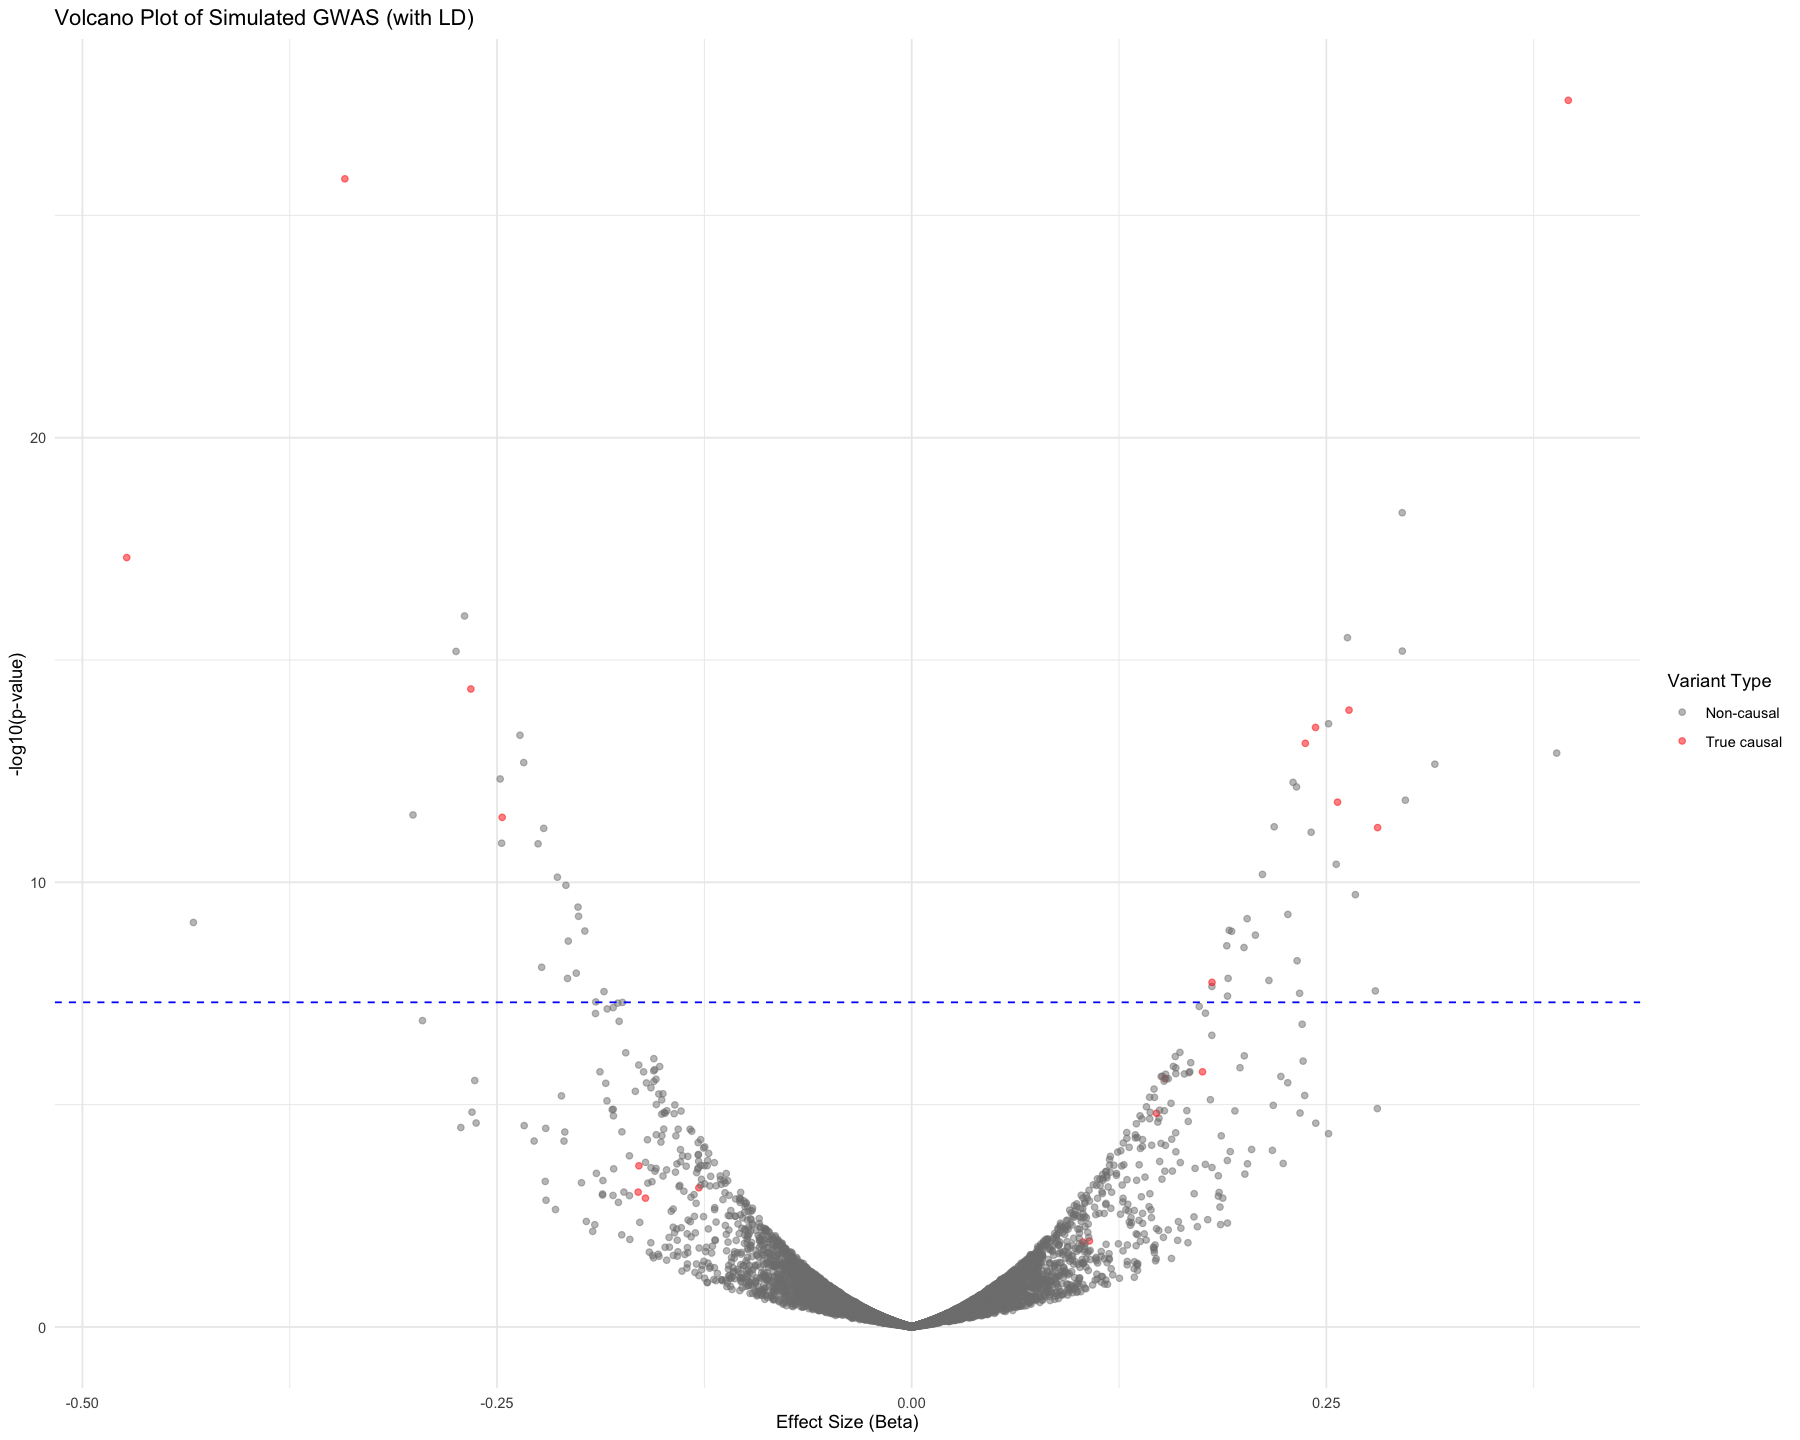

In [58]:
gwas_results %>%
  mutate(logP = -log10(p_value)) %>%
  ggplot(aes(x = beta, y = logP, color = is_causal)) +
  geom_point(alpha = 0.5) +
  scale_color_manual(values = c("grey50", "red"),
                     labels = c("Non-causal", "True causal"),
                     name = "Variant Type") +
  geom_hline(yintercept = -log10(5e-8), linetype = "dashed", color = "blue") +
  theme_minimal() +
  labs(
    title = "Volcano Plot of Simulated GWAS (with LD)",
    x = "Effect Size (Beta)",
    y = "-log10(p-value)"
  )

#### Zoomed version of manhattan plot

zoomed into a region with a causal variant in it to see the actual impact of LD

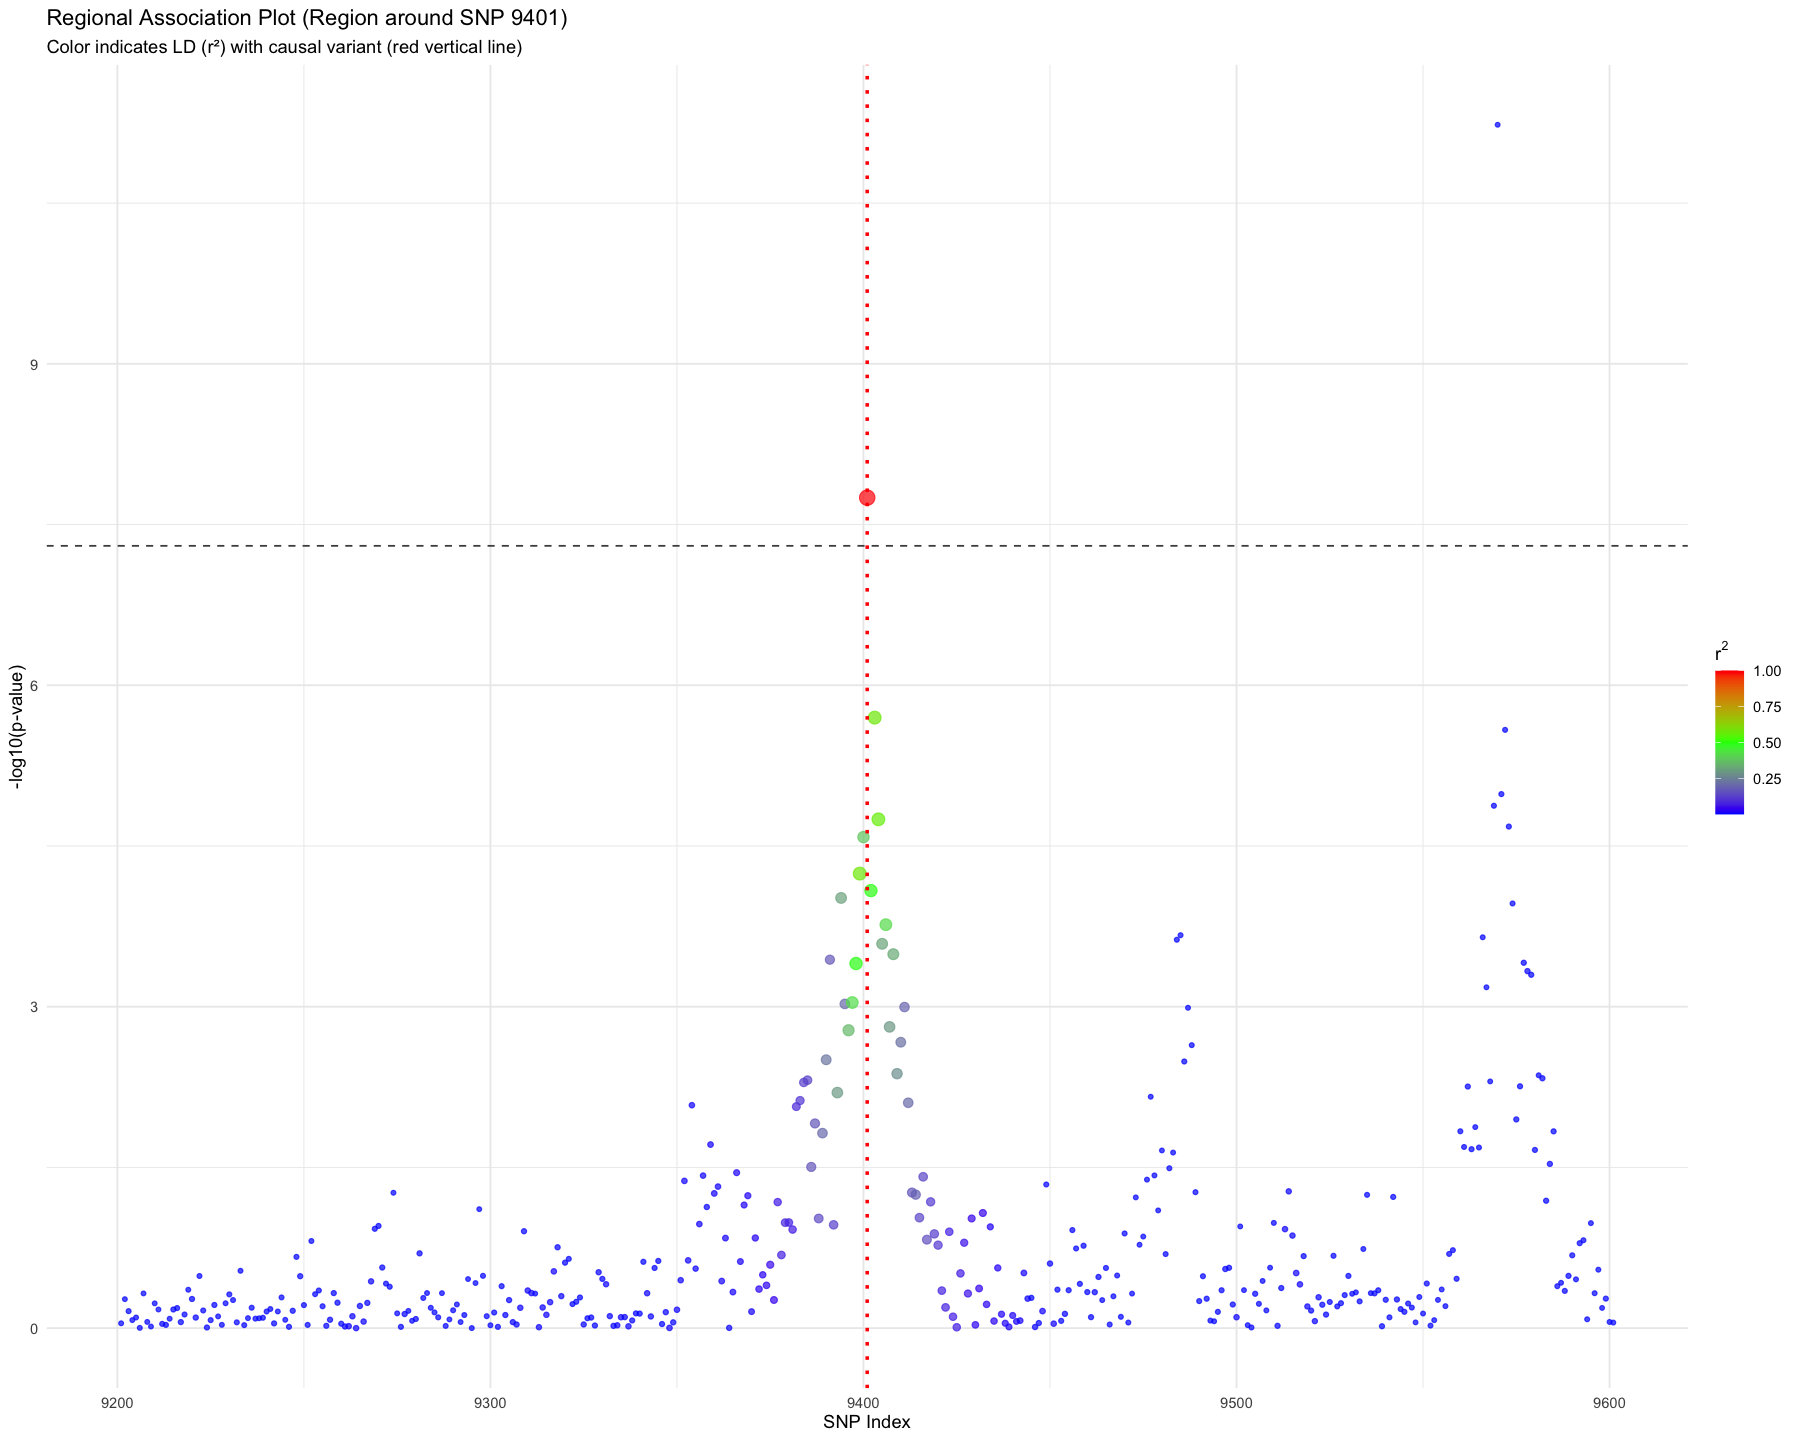

In [59]:
# Select a causal variant and plot surrounding region
focal_causal <- causal_snps[1]
region_size <- 200
region_start <- max(1, focal_causal - region_size)
region_end <- min(n_snps, focal_causal + region_size)
region_snps <- region_start:region_end

# Calculate LD with focal causal variant
ld_with_causal <- cor(genotypes[, region_snps], genotypes[, focal_causal])^2

region_data <- gwas_results[region_snps, ] %>%
  mutate(
    logP = -log10(p_value),
    r2_with_causal = ld_with_causal,
    position = region_snps
  )

ggplot(region_data, aes(x = position, y = logP)) +
  geom_point(aes(color = r2_with_causal, size = r2_with_causal), alpha = 0.7) +
  scale_color_gradient2(low = "blue", mid = "green", high = "red",
                        midpoint = 0.5, name = expression(r^2)) +
  scale_size_continuous(range = c(1, 4), guide = "none") +
  geom_hline(yintercept = -log10(5e-8), linetype = "dashed", color = "grey30") +
  geom_vline(xintercept = focal_causal, linetype = "dotted", color = "red", linewidth = 1) +
  theme_minimal() +
  labs(
    title = sprintf("Regional Association Plot (Region around SNP %d)", focal_causal),
    subtitle = "Color indicates LD (r²) with causal variant (red vertical line)",
    x = "SNP Index",
    y = "-log10(p-value)"
  )

### Summary of observations with LD:

- **Tag SNPs**: Non-Causal variants can also show association signals if they are correlated with causal ones
- **SNP Clustering:** Many nearby SNPs show association due to correlation. 
- **Broader Peaks**: Manhattan plot shows wider association regions compared to when the SNPs were independent and LD was zero
- **Challenges:** It is now harder to isolate and identify the true causal variant vs the variants that are just correlated with it.